### PCVK CM

## Bagian A

1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.

2. Terapkan transformasi brightness dan contrast (linear/log brightness).
- Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak
natural.

3. Lakukan histogram equalization untuk memperbaiki sebaran kontras.
- Bandingkan hasil visual dan histogram sebelum–sesudah.

4. Terapkan filter spasial:
- Low-pass filter untuk menghaluskan noise kulit wajah.
-  High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

## Bagian B

Jawablah dalam bentuk narasi atau tabel analisis singkat:
1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah
gelap?
-
2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan alasannya dengan
contoh hasil Anda.
-
3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling
terpengaruh?
-
4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?
-
5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk
meningkatkan readability fitur wajah sebelum tahap deteksi?
-

## Bagian C

Gunakan struktur kode seperti:

```
import cv2, numpy as np, matplotlib.pyplot as plt
img = cv2.imread('face1.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Brightness & Contrast
b, a = 30, 1.2
img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)

# Histogram Equalization
img_he = cv2.equalizeHist(img_bc)
# Spatial Filtering (contoh High-pass)
kernel_hp = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
img_hp = cv2.filter2D(img_he, -1, kernel_hp)
```

Kemudian tampilkan hasil 4 tahap (asli → BC → HE → Filter → Dithered).

In [118]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
from google.colab.patches import cv2_imshow
from skimage import io
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/CM1_PCVK'

In [120]:
# img_asli = cv.imread(f'{base_path}/face1.jpg', cv.IMREAD_COLOR)

# gray_asli = cv.cvtColor(img_asli, cv.COLOR_BGR2GRAY)
# plt.imshow(gray_asli, cmap='gray')

In [121]:
def show_images(titles, images, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

Brightness & Contrast

In [122]:
def adjust_brightness_contrast(img, brightness=30, contrast=1.2):
    """Tingkatkan kontras dan kecerahan."""
    adjusted = np.clip(img * contrast + brightness, 0, 255).astype(np.uint8)
    return adjusted

 Histogram Equalizationd

In [123]:
def equalize_hist(img):
    return cv.equalizeHist(img)


# he_img = cv.equalizeHist(bc_img)

In [124]:
def equalize_hist_color(img_rgb):
    r, g, b = cv.split(img_rgb)
    r_eq = cv.equalizeHist(r)
    g_eq = cv.equalizeHist(g)
    b_eq = cv.equalizeHist(b)
    return cv.merge((r_eq, g_eq, b_eq))


Filtering (High-Pass)

In [125]:
def filter_img(img):
    kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ])
    filter_img = cv.filter2D(img, -1, kernel)
    filter_img = cv.normalize(filter_img, None, 0, 255, cv.NORM_MINMAX)
    return filter_img


Dithering (Floyd–Steinberg)

In [126]:
def floyd_steinberg_dither(img):
    """Dithering Floyd–Steinberg untuk grayscale 8-bit."""
    dithered = img.astype(np.float32)
    h, w = dithered.shape
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = dithered[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x] = new_pixel
            error = old_pixel - new_pixel
            # Sebarkan error ke piksel sekitar
            dithered[y, x + 1] += error * 7 / 16
            dithered[y + 1, x - 1] += error * 3 / 16
            dithered[y + 1, x] += error * 5 / 16
            dithered[y + 1, x + 1] += error * 1 / 16
    return np.clip(dithered, 0, 255).astype(np.uint8)



In [127]:
import numpy as np
import cv2

def floyd_steinberg_dither_rgb(img):
    """Dithering Floyd–Steinberg untuk gambar RGB 24-bit."""
    dithered = img.copy().astype(np.float32)

    h, w, c = dithered.shape

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = dithered[y, x].copy()

            new_pixel = np.round(old_pixel / 255) * 255
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            dithered[y, x + 1]     += error * 7 / 16
            dithered[y + 1, x - 1] += error * 3 / 16
            dithered[y + 1, x]     += error * 5 / 16
            dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

Hasil

In [134]:
import itertools
import cv2 as cv

face1_asli = cv.imread(f'{base_path}/face1.jpg', cv.IMREAD_COLOR)
face1_resized = cv.resize(face1_asli, (500, 500), interpolation=cv.INTER_AREA)
face1_gray = cv.cvtColor(face1_resized, cv.COLOR_BGR2GRAY)

# --- Daftar operasi ---
operations = [
    ("Brightness/Contrast", lambda img: adjust_brightness_contrast(img, brightness=30, contrast=1.2)),
    ("Histogram Equalization", equalize_hist),
    ("High-Pass Filter", filter_img),
    ("Dithering", floyd_steinberg_dither)
]

# --- Semua urutan (4! = 24 kombinasi) ---
all_orders = list(itertools.permutations(operations))

# --- Jalankan setiap urutan ---
for idx, ops in enumerate(all_orders, start=1):
    img = face1_gray.copy()
    titles = ["Asli (Gray)"]
    imgs = [img]
    seq_names = []

    # Terapkan tiap operasi sesuai urutan
    for name, func in ops:
        img = func(img)
        imgs.append(img)
        seq_names.append(name)

    titles += seq_names

    print(f"\n=== Kombinasi {idx:02d}: {' -> '.join(seq_names)} ===")
    show_images(titles, imgs)


Output hidden; open in https://colab.research.google.com to view.

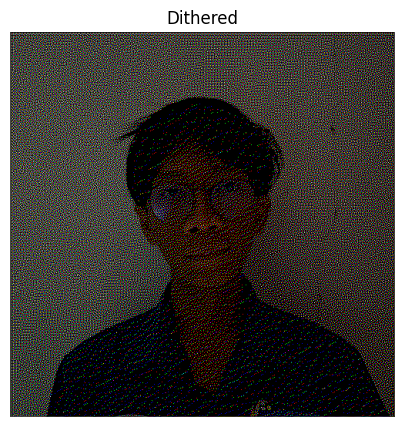

In [131]:
face1_asli = cv.imread(f'{base_path}/face1.jpg', cv.IMREAD_COLOR)
face1_resized = cv.resize(face1_asli, (500, 500), interpolation=cv.INTER_AREA)
face1_rgb = cv.cvtColor(face1_resized, cv.COLOR_BGR2RGB)

ditering = floyd_steinberg_dither_rgb(face1_rgb)
show_images(
    ['Dithered'],
    [ditering]
)

## Bagian D - Analisis Akhir & Kesimpulan

Tuliskan 1 halaman analisis:

1. Urutan proses terbaik untuk menghasilkan wajah paling siap recognition
- Urutan terbaik yaitu High-Pass Filter -> Brightness/Contrast -> Histogram Equalization -> Dithering. Karens detail lebih jelas

2. Perbandingan nilai PSNR antara citra asli yang memiliki pencahanyaan baik dan hasil pra-
pemrosesan


In [138]:
def gaussian_blur(image, kernel_size):
    return cv.GaussianBlur(image, (kernel_size, kernel_size), 0)

In [144]:
def psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 10 * np.log10((max_pixel ** 2) / mse)

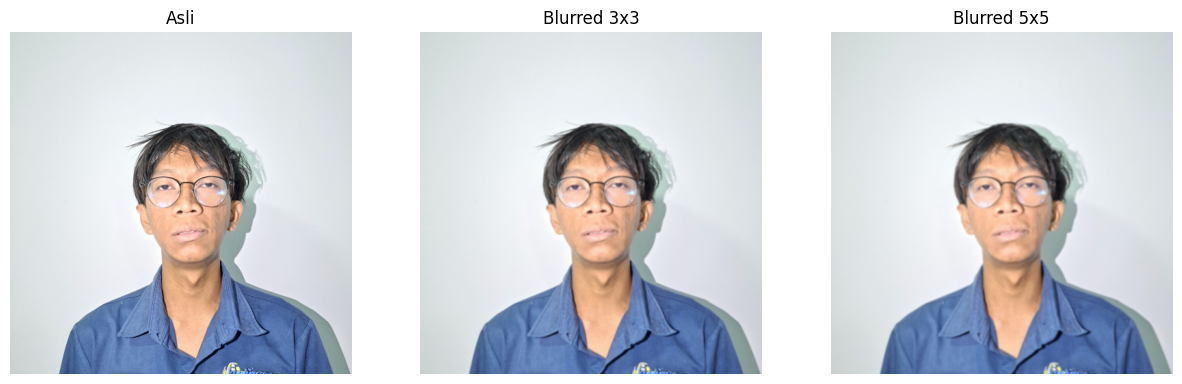

In [143]:
face2_asli = cv.imread(f'{base_path}/face2.jpg', cv.IMREAD_COLOR)
face2_resized = cv.resize(face2_asli, (500, 500), interpolation=cv.INTER_AREA)
face2_rgb = cv.cvtColor(face2_resized, cv.COLOR_BGR2RGB)

face2_blur3 = gaussian_blur(face2_rgb, 3)
face2_blur5 = gaussian_blur(face2_rgb, 5)

show_images(
    ['Asli','Blurred 3x3', 'Blurred 5x5'],
    [face2_rgb, face2_blur3, face2_blur5]
)

In [146]:
# print(f'PSNR asli: {psnr(face2_rgb, face2_rgb)}')
print(f'PSNR blurred 3x3: {psnr(face2_rgb, face2_blur3)}')
print(f'PSNR blurred 5x5: {psnr(face2_rgb, face2_blur5)}')

PSNR blurred 3x3: 35.136863708496094
PSNR blurred 5x5: 32.926055908203125


-

3. Rekomendasi metode peningkatan kualitas wajah untuk sistem pengenalan wajah real-time
-